In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
air_df = pd.read_csv('Airdata.csv')
air_df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
0,1/1/2020 0:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37
1,1/1/2020 1:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53
2,1/1/2020 2:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80
3,1/1/2020 3:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80
4,1/1/2020 4:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43


In [4]:
air_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DateTime        8784 non-null   object 
 1   Temperature     8784 non-null   float64
 2   Humidity        8784 non-null   int64  
 3   Wind_Speed      8784 non-null   float64
 4   Wind_Direction  8784 non-null   float64
 5   NO2_Location_A  8664 non-null   float64
 6   NO2_Location_B  8204 non-null   float64
 7   NO2_Location_C  8652 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 549.1+ KB


In [5]:
print('Number of missing values:')
for col in air_df.columns:
    n_MV = sum(air_df[col].isna())
    print('{}:{}'.format(col,n_MV))

Number of missing values:
DateTime:0
Temperature:0
Humidity:0
Wind_Speed:0
Wind_Direction:0
NO2_Location_A:120
NO2_Location_B:580
NO2_Location_C:132


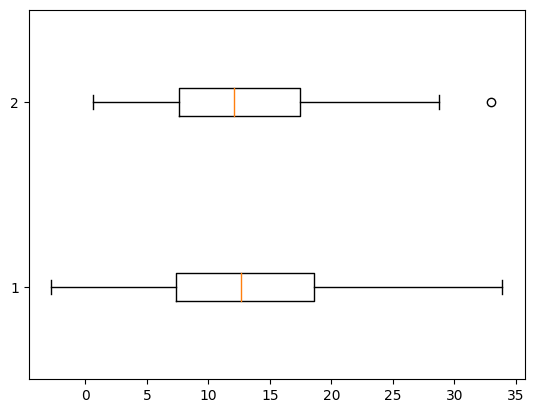

In [12]:
BM_MV = air_df.NO2_Location_A.isna()
MV_Labels = ['With Missing Values','Without Missing Values']

box_sr = pd.Series('',index = BM_MV.unique())

for poss in BM_MV.unique():
    BM = BM_MV == poss
    box_sr[poss] = air_df[BM]['Temperature']
    
plt.boxplot(box_sr, vert=False)
plt.yticks([1,2], MV_Labels)
plt.show()
# no significant change in the Temperature value between the 2 populations
# this ishows that a change in Temp could not have caused or influenced the occurrence
# of missing values under NO2_Location_A

In [10]:
pd.Series('',index = BM_MV.unique())

False    
True     
dtype: object

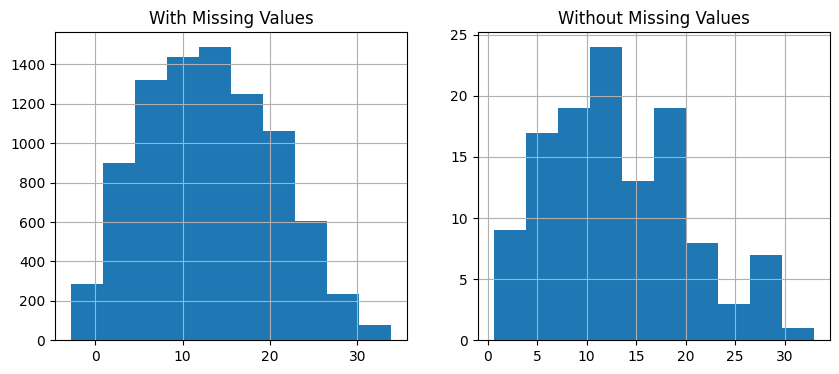

In [23]:
BM_MV = air_df.NO2_Location_A.isna()
temp_range = (air_df['Temperature'].min(), air_df['Temperature'].max())
MV_labels = ['With Missing Values','Without Missing Values']

plt.figure(figsize=(10,4))

for i, poss in enumerate(BM_MV.unique()):
    plt.subplot(1,2,i+1)
    BM = BM_MV == poss
    air_df[BM]['Temperature'].hist()
    plt.xlim = temp_range
    plt.title(MV_labels[i])
plt.show()
# no significant change in the Temperature value between the 2 populations
# this ishows that a change in Temp could not have caused or influenced the occurrence
# of missing values under NO2_Location_A

In [24]:
from scipy.stats import ttest_ind
BM_MV = air_df.NO2_Location_A.isna()
ttest_ind(air_df[BM_MV]['Temperature'], air_df[~BM_MV]['Temperature'])
# the high p-value show there is no meaningful association with the missing values in NO2_Location_A
# affecting the Temperature attribute

TtestResult(statistic=0.05646499065315542, pvalue=0.9549726689684548, df=8782.0)

In [27]:
air_df.NO2_Location_A.isna()

0       False
1       False
2        True
3       False
4       False
        ...  
8779    False
8780    False
8781    False
8782    False
8783    False
Name: NO2_Location_A, Length: 8784, dtype: bool

In [30]:
# the tilde sign looks for the "false" values
air_df[~BM_MV]['Temperature'].head(10)

0     2.180529
1     1.490529
3     1.430529
4     0.840529
5     1.160529
6     1.680529
8     1.300529
9     0.410529
10   -0.309471
11    1.140529
Name: Temperature, dtype: float64

In [31]:
air_df[BM_MV]['Temperature'].head(10)

2      1.690529
7      1.700529
25     3.020529
71     7.530528
75     8.070529
165    5.750528
307    8.690529
323    6.850529
600    5.070528
753    7.550529
Name: Temperature, dtype: float64

In [42]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df, str_att_name, BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}
    
    labels=[]
    box_sr = pd.Series('',index=BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])
    
    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()
    
    plt.figure(figsize=(10,4))
        
    att_range = (df[str_att_name].min(), df[str_att_name].max())
    
    for i, poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])
    plt.show()

    group_1_date = df[BM_MV][str_att_name].dropna()
    group_2_date = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_date, group_2_date).pvalue

    print('p-value of t-test: {}'.format(p_value))

Diagnosis Analysis of Missing Values for Temperature:


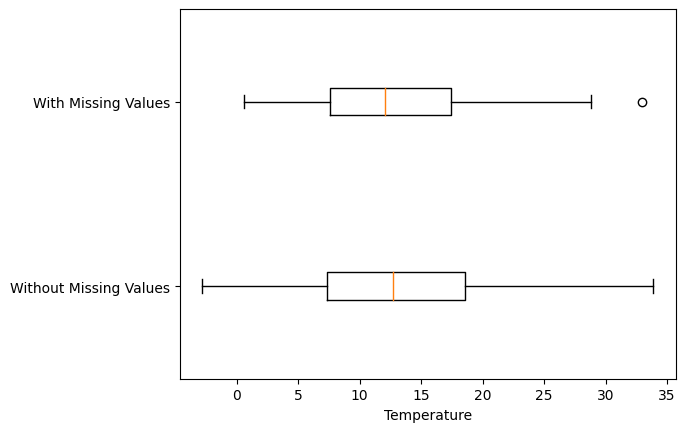

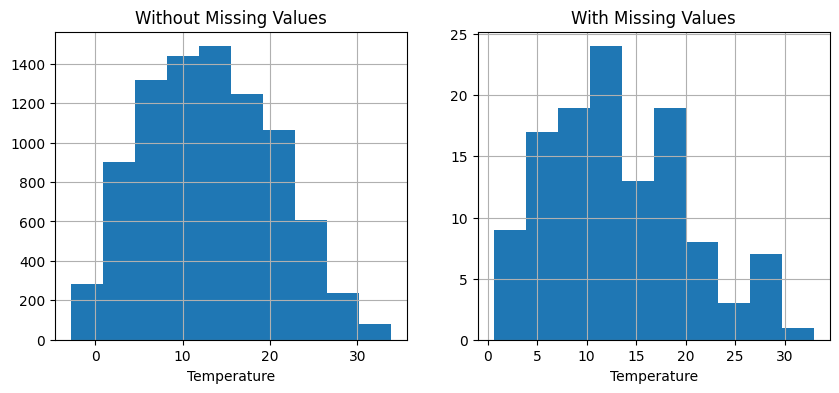

p-value of t-test: 0.9549726689684548
- - - - - - - - - - - - - divider - - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Humidity:


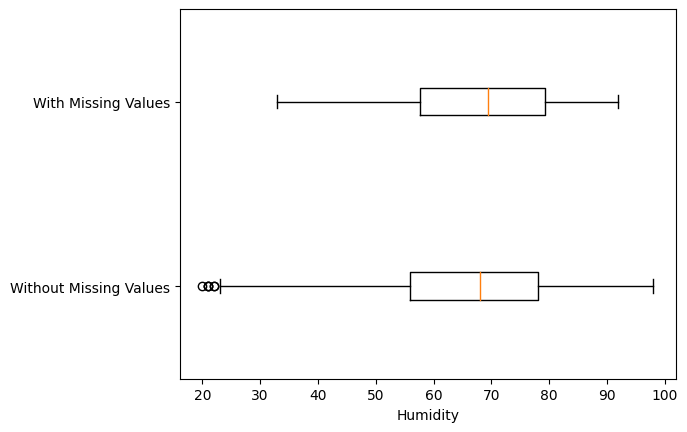

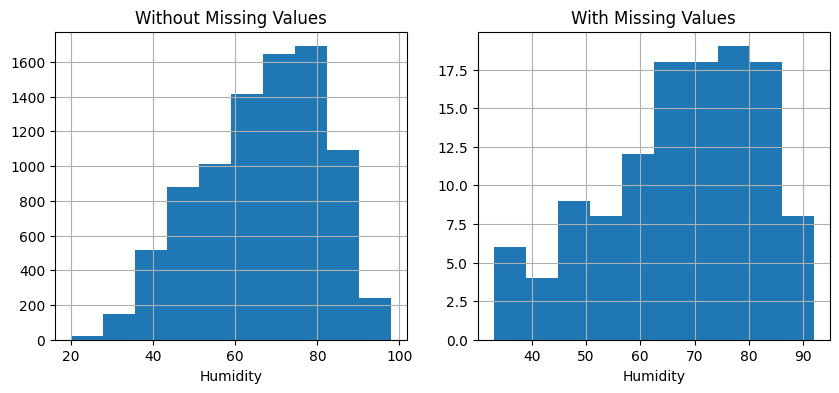

p-value of t-test: 0.5593319830352679
- - - - - - - - - - - - - divider - - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Wind_Speed:


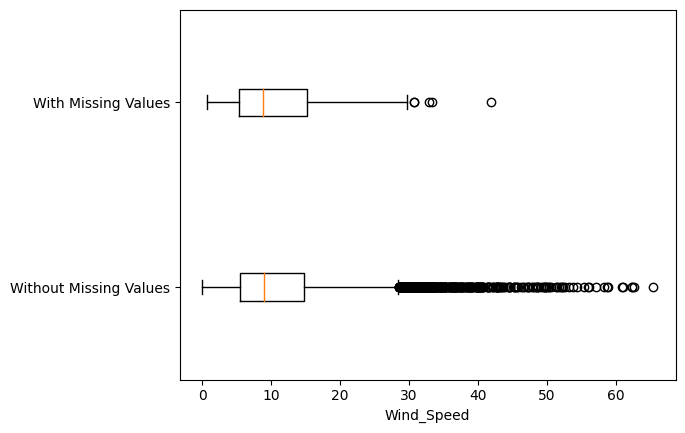

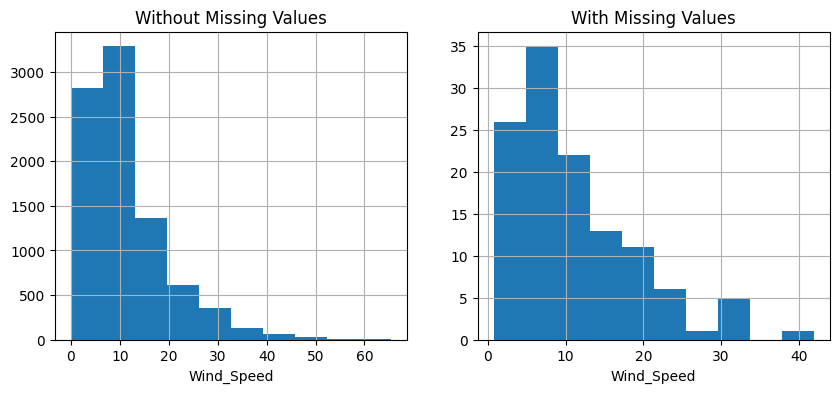

p-value of t-test: 0.8172472856083665
- - - - - - - - - - - - - divider - - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Wind_Direction:


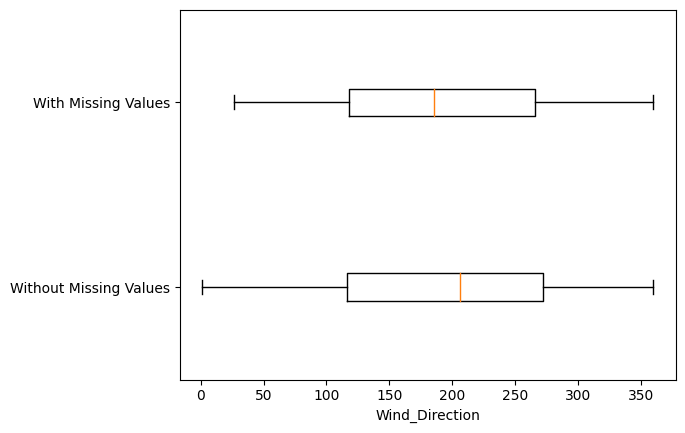

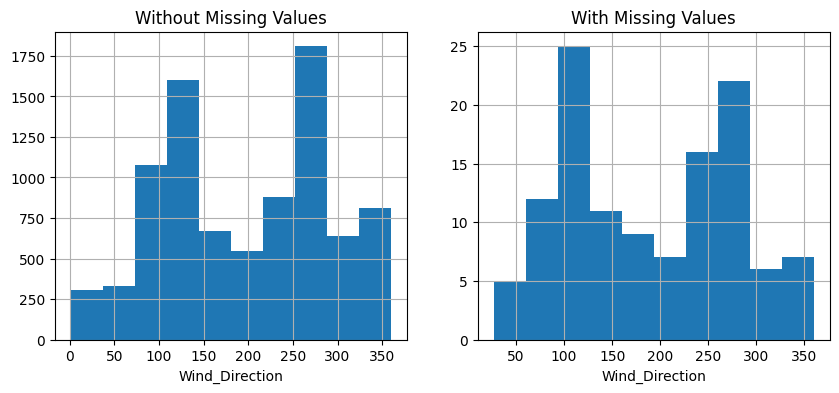

p-value of t-test: 0.39869195396670654
- - - - - - - - - - - - - divider - - - - - - - - - - - - 


In [45]:
numerical_attributes = ['Temperature','Humidity','Wind_Speed','Wind_Direction']
BM_MV = air_df['NO2_Location_A'].isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(air_df, att, BM_MV)
    print('- - - - - - - - - - - - - divider - - - - - - - - - - - - ')

In [46]:
air_df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
0,1/1/2020 0:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37
1,1/1/2020 1:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53
2,1/1/2020 2:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80
3,1/1/2020 3:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80
4,1/1/2020 4:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43


In [48]:
air_df['DateTime'] = pd.to_datetime(air_df.DateTime)

In [49]:
air_df['month'] = air_df.DateTime.dt.month
air_df['day'] = air_df.DateTime.dt.day
air_df['hour'] = air_df.DateTime.dt.hour
air_df['weekday'] = air_df.DateTime.dt.day_name()

In [50]:
air_df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C,month,day,hour,weekday
0,2020-01-01 00:00:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37,1,1,0,Wednesday
1,2020-01-01 01:00:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53,1,1,1,Wednesday
2,2020-01-01 02:00:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80,1,1,2,Wednesday
3,2020-01-01 03:00:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80,1,1,3,Wednesday
4,2020-01-01 04:00:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43,1,1,4,Wednesday


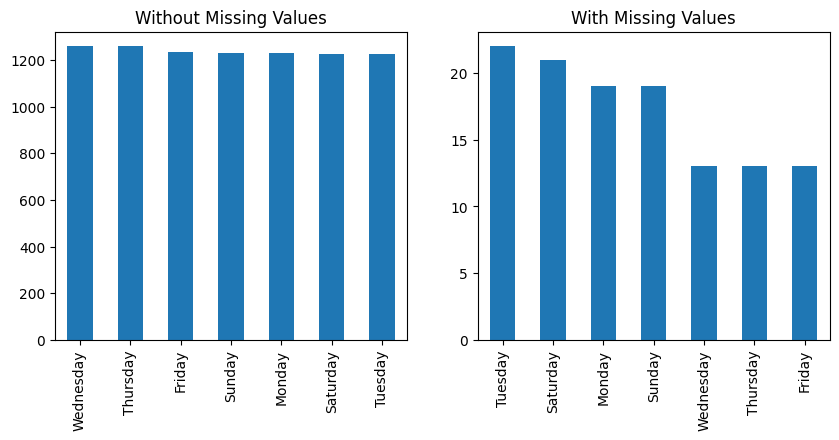

In [51]:
BM_MV = air_df.NO2_Location_A.isna()
MV_labels = ['Without Missing Values', 'With Missing Values']

plt.figure(figsize=(10,4))
for i, poss in enumerate(BM_MV.unique()):
    plt.subplot(1,2,i+1)
    BM = BM_MV == poss
    air_df[BM].weekday.value_counts().plot.bar()
    plt.title(MV_labels[i])
plt.show()

In [56]:
from scipy.stats import chi2_contingency
BM_MV = air_df['NO2_Location_A'].isna()
contingency_table = pd.crosstab(BM_MV, air_df.weekday)
contingency_table

weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
NO2_Location_A,,,,,,,
False,1235,1229,1227,1229,1259,1226,1259
True,13,19,21,19,13,22,13


In [57]:
chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=6.048964133655503, pvalue=0.41772751510388023, dof=6, expected_freq=array([[1230.95081967, 1230.95081967, 1230.95081967, 1230.95081967,
        1254.62295082, 1230.95081967, 1254.62295082],
       [  17.04918033,   17.04918033,   17.04918033,   17.04918033,
          17.37704918,   17.04918033,   17.37704918]]))